In [1]:
import pandas as pd
import numpy as np
import json
import xgboost as xgb
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report

In [2]:
df = pd.read_parquet("../data/aircraft engine/PM_train.parquet")

In [3]:
test_df = pd.read_csv("../data/aircraft engine/PM_test.csv")

In [4]:
truth_df = pd.read_csv("../data/aircraft engine/PM_truth.csv")

In [5]:
xgb_model = xgb.XGBClassifier(
    colsample_bytree=0.8,
    gamma=0.1,
    grow_policy="lossguide",
    learning_rate=0.12964140540905078,
    max_depth=None,
    n_estimators=3000,
    objective="binary:logistic",
    reg_alpha=0.1,
    reg_lambda=10,
    subsample=1,
    random_state=42,
    scale_pos_weight=11
)

In [6]:
df['RULC'] = df['RUL'].map(lambda x: 1 if x<30 else 0)
x = df.drop(['id','RUL', 'cycle', 'max', 'RULC'], axis=1)
y = df['RULC']
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.25, random_state=42)

In [7]:
x_test_df = test_df.drop(['id','cycle'], axis=1)

In [8]:
xgb_model.fit(x_train,y_train)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=0.8, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric=None, feature_types=None,
              gamma=0.1, grow_policy='lossguide', importance_type=None,
              interaction_constraints=None, learning_rate=0.12964140540905078,
              max_bin=None, max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=None, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=3000, n_jobs=None,
              num_parallel_tree=None, random_state=42, ...)

In [9]:
y_pred = xgb_model.predict(x_test)

In [10]:
accuracy_score(y_test,y_pred)

0.9563784412563009

In [11]:
test_df['pred'] = xgb_model.predict(x_test_df)

In [12]:
test_df

,id,cycle,setting1,setting2,setting3,s1,s2,s3,s4,s5,...,s13,s14,s15,s16,s17,s18,s19,s20,s21,pred
0,1,1,0.0023,0.0003,100.0,518.67,643.02,1585.29,1398.21,14.62,...,2388.03,8125.55,8.4052,0.03,392,2388,100.0,38.86,23.3735,0
1,1,2,-0.0027,-0.0003,100.0,518.67,641.71,1588.45,1395.42,14.62,...,2388.06,8139.62,8.3803,0.03,393,2388,100.0,39.02,23.3916,0
2,1,3,0.0003,0.0001,100.0,518.67,642.46,1586.94,1401.34,14.62,...,2388.03,8130.10,8.4441,0.03,393,2388,100.0,39.08,23.4166,0
3,1,4,0.0042,0.0000,100.0,518.67,642.44,1584.12,1406.42,14.62,...,2388.05,8132.90,8.3917,0.03,391,2388,100.0,39.00,23.3737,0
4,1,5,0.0014,0.0000,100.0,518.67,642.51,1587.19,1401.92,14.62,...,2388.03,8129.54,8.4031,0.03,390,2388,100.0,38.99,23.4130,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
13091,100,194,0.0049,0.0000,100.0,518.67,643.24,1599.45,1415.79,14.62,...,2388.00,8213.28,8.4715,0.03,394,2388,100.0,38.65,23.1974,1
13092,100,195,-0.0011,-0.0001,100.0,518.67,643.22,1595.69,1422.05,14.62,...,2388.09,8210.85,8.4512,0.03,395,2388,100.0,38.57,23.2771,1
13093,100,196,-0.0006,-0.0003,100.0,518.67,643.44,1593.15,1406.82,14.62,...,2388.04,8217.24,8.4569,0.03,395,2388,100.0,38.62,23.2051,1
13094,100,197,-0.0038,0.0001,100.0,518.67,643.26,1594.99,1419.36,14.62,...,2388.08,8220.48,8.4711,0.03,395,2388,100.0,38.66,23.2699,1


In [13]:
pred_cycle = test_df.groupby('id', as_index=False)['pred'].max()

In [14]:
pred_cycle['pred']

0     0
1     0
2     0
3     0
4     0
     ..
95    0
96    0
97    0
98    0
99    1
Name: pred, Length: 100, dtype: int64

In [15]:
truth_df['RULC'] = truth_df['cycle'].map(lambda x: 1 if x<30 else 0)

In [16]:
truth_df['pred_RULC'] = pred_cycle['pred']

In [17]:
truth_df

,id,cycle,RULC,pred_RULC
0,1,112,0,0
1,2,98,0,0
2,3,69,0,0
3,4,82,0,0
4,5,91,0,0
...,...,...,...,...
95,96,137,0,0
96,97,82,0,0
97,98,59,0,0
98,99,117,0,0


In [18]:
(truth_df['RULC'] == truth_df['pred_RULC']).sum()

91

In [19]:
accuracy_score(truth_df['RULC'], truth_df['pred_RULC'])

0.91

In [20]:
print(classification_report(truth_df['RULC'], truth_df['pred_RULC']))

              precision    recall  f1-score   support

           0       0.93      0.95      0.94        75
           1       0.83      0.80      0.82        25

    accuracy                           0.91       100
   macro avg       0.88      0.87      0.88       100
weighted avg       0.91      0.91      0.91       100



In [21]:
from sklearn.metrics import confusion_matrix
cm = confusion_matrix(truth_df['RULC'], truth_df['pred_RULC'])
print(cm)

[[71  4]
 [ 5 20]]


In [23]:
import matplotlib.pyplot as plt
from sklearn.metrics import ConfusionMatrixDisplay

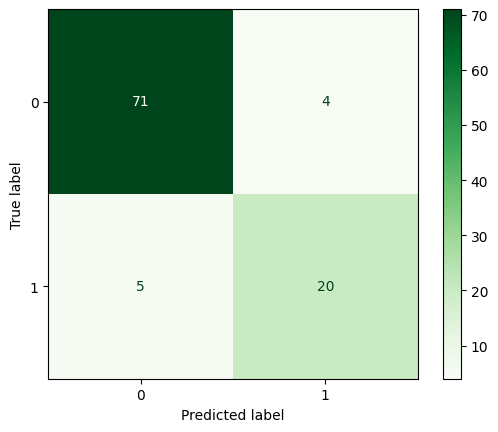

In [25]:
cm = ConfusionMatrixDisplay(confusion_matrix(truth_df['RULC'], truth_df['pred_RULC']))
cm.plot(cmap=plt.cm.Greens)